Problem Description:
Consider the task of image classification using a standard visual recognition dataset.
The objective of this part is to study and compare the performance, robustness, and
computational efficiency of convolutional neural network (CNN) architectures trained
from scratch and using transfer learning techniques.
You are required to use the CIFAR-100 dataset, which consists of 100 object classes.
Each input sample is a 32×32 RGB image, and the model output is a categorical label
corresponding to one of the 100 object categories. The dataset contains 50,000 training
images and 10,000 test images.

<div align="center">
----------------------------------------------------------------------------------------------XXXXXXXXXXXXXXXXXXXXXX----------------------------------------------------------------------------------------------
</div>

Loading and inspecting the data to understand the given dataset

In [42]:
#import necessary libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch

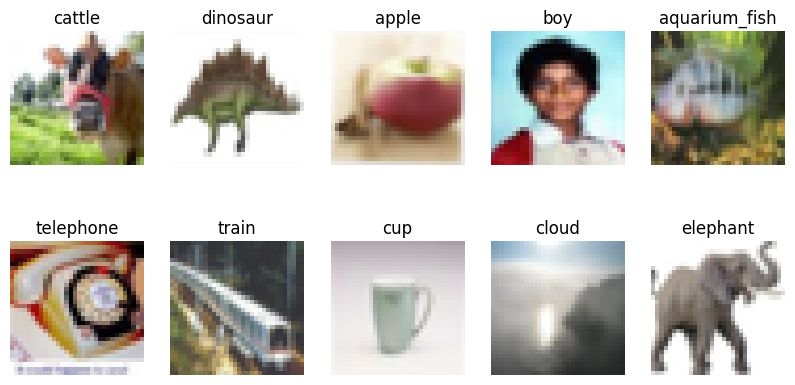

In [32]:
#method to load the dataset pickle file and view/process the images
def load_cifar100(file_path):
    """
    this method uses pickle library to load the train, test, and the metadata file, returns a dictionary
    """
    with open(file_path, 'rb') as f:
        data = pickle.load(f, encoding='bytes')
    return data

train_data = load_cifar100(r'D:\machine_learning\datasets\cifar_100\cifar-100-python\train')
test_data = load_cifar100(r'D:\machine_learning\datasets\cifar_100\cifar-100-python\test')
metadata = load_cifar100(r'D:\machine_learning\datasets\cifar_100\cifar-100-python\meta')

# print(train_data.keys())  #prints - dict_keys([b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data'])

fine_label_names = metadata[b'fine_label_names'] #this reads the metadatafile and gets the class names

plt.figure(figsize=(10,5))

for i in range(10):
    img = train_data[b'data'][i].reshape(3,32,32) #since each image is 3072 bytes long we need to reshape the numpy array so that image can be truly represented, here I have refactored the 3072 bytes into 3 channel images of 32x32 resolution. currently it is (Channels X Height X Width)
    img = np.transpose(img, (1,2,0)) # taking a transpose of the image from (Channels X Height X Width) to (Height X Width X Channels) so that matplotlib can plot it, while pytorch uses CxHxW, matplotlib uses HxWxC

    label = train_data[b'fine_labels'][i] # this gets the class number from the train file
    class_name = fine_label_names[label].decode('utf-8') #this maps the class name with class number from metadata and training file


    plt.subplot(2,5, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off') #remove the axis markings
plt.show();

In [ ]:
#check all available classes
label_names = [name.decode('utf-8') for name in fine_label_names]
for i, name in enumerate(label_names):
    print(f"{i}: {name}")
#there are 100 classes in the dataset

0: apple
1: aquarium_fish
2: baby
3: bear
4: beaver
5: bed
6: bee
7: beetle
8: bicycle
9: bottle
10: bowl
11: boy
12: bridge
13: bus
14: butterfly
15: camel
16: can
17: castle
18: caterpillar
19: cattle
20: chair
21: chimpanzee
22: clock
23: cloud
24: cockroach
25: couch
26: crab
27: crocodile
28: cup
29: dinosaur
30: dolphin
31: elephant
32: flatfish
33: forest
34: fox
35: girl
36: hamster
37: house
38: kangaroo
39: keyboard
40: lamp
41: lawn_mower
42: leopard
43: lion
44: lizard
45: lobster
46: man
47: maple_tree
48: motorcycle
49: mountain
50: mouse
51: mushroom
52: oak_tree
53: orange
54: orchid
55: otter
56: palm_tree
57: pear
58: pickup_truck
59: pine_tree
60: plain
61: plate
62: poppy
63: porcupine
64: possum
65: rabbit
66: raccoon
67: ray
68: road
69: rocket
70: rose
71: sea
72: seal
73: shark
74: shrew
75: skunk
76: skyscraper
77: snail
78: snake
79: spider
80: squirrel
81: streetcar
82: sunflower
83: sweet_pepper
84: table
85: tank
86: telephone
87: television
88: tiger
89: t

In [ ]:
#check how many images are available per class
label_counts = Counter(train_data[b'fine_labels'])

for label, count in sorted(label_counts.items()):
    print(f"{label_names[label]}: {count}")

#conclusion - dataset is very balanced with 500 images for every class.

apple: 500
aquarium_fish: 500
baby: 500
bear: 500
beaver: 500
bed: 500
bee: 500
beetle: 500
bicycle: 500
bottle: 500
bowl: 500
boy: 500
bridge: 500
bus: 500
butterfly: 500
camel: 500
can: 500
castle: 500
caterpillar: 500
cattle: 500
chair: 500
chimpanzee: 500
clock: 500
cloud: 500
cockroach: 500
couch: 500
crab: 500
crocodile: 500
cup: 500
dinosaur: 500
dolphin: 500
elephant: 500
flatfish: 500
forest: 500
fox: 500
girl: 500
hamster: 500
house: 500
kangaroo: 500
keyboard: 500
lamp: 500
lawn_mower: 500
leopard: 500
lion: 500
lizard: 500
lobster: 500
man: 500
maple_tree: 500
motorcycle: 500
mountain: 500
mouse: 500
mushroom: 500
oak_tree: 500
orange: 500
orchid: 500
otter: 500
palm_tree: 500
pear: 500
pickup_truck: 500
pine_tree: 500
plain: 500
plate: 500
poppy: 500
porcupine: 500
possum: 500
rabbit: 500
raccoon: 500
ray: 500
road: 500
rocket: 500
rose: 500
sea: 500
seal: 500
shark: 500
shrew: 500
skunk: 500
skyscraper: 500
snail: 500
snake: 500
spider: 500
squirrel: 500
streetcar: 500
su

Question A1. Design and train a convolutional neural network from scratch for image classification on the CIFAR-100 dataset. The network should be of moderate size and computationally feasible to train using available resources. Clearly describe the architecture, including the number of convolutional layers, kernel sizes, activation functions, and pooling operations. Train the model and report the training and validation accuracy. Comment on the convergence behavior and overall performance.

In [44]:
# Convert train data in usable format for pytorch
X_train = train_data[b'data'].reshape(-1, 3, 32, 32)
y_train = np.array(train_data[b'fine_labels'])

# Convert test data in usable format for pytorch
X_test = test_data[b'data'].reshape(-1, 3, 32, 32)
y_test = np.array(test_data[b'fine_labels'])

# normalizing the data
X_train = X_train / 255.0
X_test = X_test / 255.0

# convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)